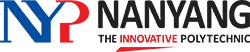

# IT2311 Assignment - Task 1a: Data Preparation

For this task, you are required to perform data understanding to examine your dataset and data cleaning to prepare the data for task 2 and 3.

Rename **DataPreparationStarter.ipynb** to **\<AdminNo\>_DataPreparation.ipynb** and complete the following sub-tasks:

Complete the following sub-tasks:

1. **Load Data**: Load your dataset
2. **Data Understanding**: Examine your dataset
3. **Data Cleaning**: Clean your data and perform all necessary pre-processing tasks
4. **Save Data**: Save the cleaned data for next task

For each sub-task, perform the necessary steps and **explain the rationale taken for each step in this Jupyter notebook**. 

**Done by: Wong Kang Bin 244423Q**

## Import libraries and download the packages

In [15]:
import pandas as pd
import nltk
from nltk.probability import FreqDist #Used for word frequency distribution
from nltk.tokenize import word_tokenize 
import string
import matplotlib.pyplot as plt

## Load Data

In [16]:
task1_df_wb = pd.read_json('Task_1_TM_world_bank_projects_subset.json', orient='records', lines=True)
task1_df_wb.head()

,project_id,document_text,document_type
0,P170640,The World Bank\n Public Information and Awaren...,APPROVAL
1,P007810,Document of\nThe World Bank\nFOR OFFICIAL USE ...,APPROVAL
2,P002034,Document of\nFILE COPY The World Bank\nFOR OFF...,APPROVAL
3,P003542,Document of\nThe World Bank\nFOR OFFICIAL USE ...,REVIEW
4,P109683,Independent Evaluation Group (IEG) Implementat...,REVIEW


## Data Understanding




(a) Number of rows and collumns used in this dataset

In [17]:

task1_df_wb.shape
# It generates 3000 rows and 3 columns

(3000, 3)

(b) Validate if there are any missing rows

In [18]:
task1_df_wb.isnull().sum()
# No missing data found

project_id       0
document_text    0
document_type    0
dtype: int64

(c) Duplicates Check

In [19]:
# Check if the entire row is a duplicate
duplicate_rows_check = task1_df_wb.duplicated().sum()
print("Total identical rows: ", duplicate_rows_check)

# Check if there are more than 1 record in the same project using project_id
project_id_duplicates_check = task1_df_wb['project_id'].duplicated().sum()
print("Total number of projects with more than 1 record:", project_id_duplicates_check)

Total identical rows:  0
Total number of projects with more than 1 record: 226


Even though there may be duplicated project IDs, we can reveal that there are unique documents in the same project. Thus, To ensure that the model is unbiased, we will not be removing any duplicates to preserve the data volume.

(d) Data exploration with different visualisations

In [20]:
# (1) Get frequency distribution of all words from the document_text collumn

all_words = [word.lower() for sent in task1_df_wb.document_text for word in word_tokenize(sent)]
# print first 10 words
print (all_words[:10])

['the', 'world', 'bank', 'public', 'information', 'and', 'awareness', 'services', 'for', 'vulnerable']


<FreqDist with 1106297 samples and 40039586 outcomes>


<Axes: xlabel='Samples', ylabel='Counts'>

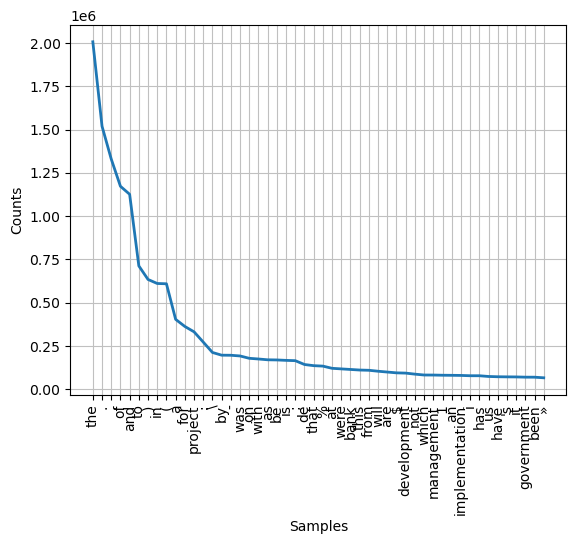

In [21]:
freq_dist = nltk.FreqDist(all_words)
print (freq_dist)

# plot the frequency distribution of the top 50 words
freq_dist.plot(50, cumulative=False)

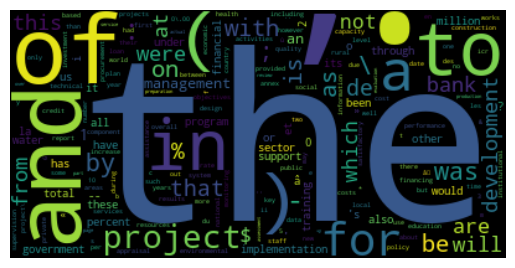

In [22]:
# (2) Word Cloud
from wordcloud import WordCloud
wcloud = WordCloud().generate_from_frequencies(freq_dist)

# plot the wordcloud
import matplotlib.pyplot as plt
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Based on the frequency distribution and the word cloud above, majority of the common frequently appeared words are stop words, punctuations and the generic topic on banks. Additionally, it also reveals that the domain-specific terms like 'World Bank Project' are dominant. This justifies that apart from just removing the stop words and punctuations, the stop words list should be customized to remove those domain-specific terms. This helps to ensure that the LDA model that will be used in topic modelling for task 1b focuses primarily on actual project themes other than just the World Bank Terminologies. Punctuations and whitespace characters will be removed as well.

C:\Users\Kang Bin\AppData\Local\Temp\ipykernel_31704\2228795816.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(task1_df_wb['document_type']).plot.bar(title="Document Type Distribution")


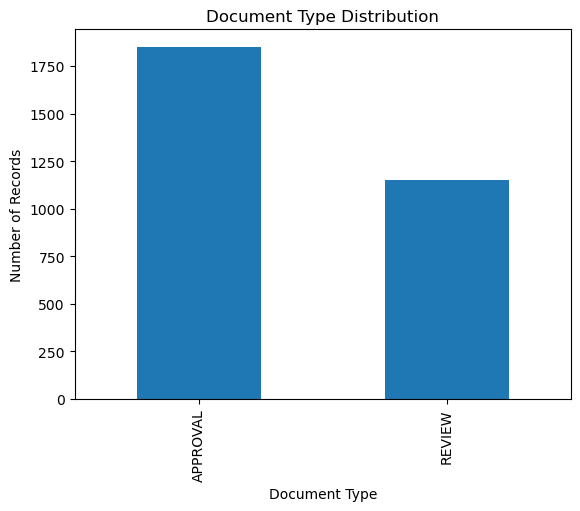

In [23]:
# (3) Document type distribution
plt.figure()
pd.value_counts(task1_df_wb['document_type']).plot.bar(title="Document Type Distribution")
plt.xlabel("Document Type")
plt.ylabel("Number of Records")
plt.show()

In [24]:
# See exact number of records based on document type
task1_df_wb['document_type'].value_counts()

document_type
APPROVAL    1850
REVIEW      1150
Name: count, dtype: int64

At least 60% of the documents are approved while the remaining documents are undergoing a review in process.

In [25]:
# (4) Detecting number of rows with non-English characters
import re

# Detect any row that has non-English (non-ASCII) characters
# This catches the Arabic, the musical notes, and unicode characters
unicode_mask = task1_df_wb['document_text'].str.contains(r'[^\x00-\x7F]', na=False)
unicode_samples = task1_df_wb[unicode_mask]

# Discovery: Specifically check for the unicode text representation identified from json data
# These are arrange in the form of hexadecimals
unicode_text_rep_mask = task1_df_wb['document_text'].str.contains(r'[\u0000-\u9fff]', na=False)
unicode_text_rep_count = task1_df_wb[unicode_text_rep_mask]

print(f"Discovery: Found {len(unicode_samples)} documents with Unicode characters/Arabic text.")
print(f"Discovery: Found {len(unicode_text_rep_count)} documents with Unicode text representations.")

# Musical notes are additional unicode characters, we will verify and see if any documents shows such text
notes_check = task1_df_wb[task1_df_wb['document_text'].str.contains(r'[♪♫]', na=False)]
print(f"Musical notes found: {len(notes_check)}")

Discovery: Found 2722 documents with Unicode characters/Arabic text.
Discovery: Found 2989 documents with Unicode text representations.
Musical notes found: 0


These characters do not create semantic meaning for topic modelling in English. Retaining them could potentially introduce noises and create meaningless topics. Thus the regex filter [^\x00-\x7F] will be applied during the cleaning phase to ensure that all text are standardise.

## Data Cleaning




In [ ]:
# Define a single function to perform all data cleaning tasks
def clean_text_task1a(text):
    # 1. Remove all non-ASCII characters using Regex Expressions
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # 2 Remove whitspace characters including escape characters (\n, \t, etc)
    text = re.sub(r'\s+', ' ', text)

    # 3. Remove punctuations
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 4. Remove numbers attached to words or standalone numbers
    text = re.sub(r'\w*\d\w*', ' ', text)  # words with number -> E.g 3d')
    
    # 5. Make all text lower case
    text = text.lower().strip()

    # 6. Removing single characters and short words by keeping words that have at least 3 characters
    # Words like R E S T R I C T E D will automatically be removed since they spaced out

    clean_words = [w for w in text.split() if len(w) > 3] 
   
    return " ".join(clean_words)

task1_df_wb['document_text'] = task1_df_wb['document_text'].apply(lambda x: clean_text_task1a(x))

# After removing the non-ASCII characters, I discovered that the rows suddenly becomes empty
# Thus, we try and remove those empty rows.
empty_rows_after_cleaning = task1_df_wb[task1_df_wb['document_text'] == ""]
print(f"Number of documents removed because they were non-English: {len(empty_rows_after_cleaning)}")

# Keep only the English documents for Task 1b
task1_df_wb = task1_df_wb[task1_df_wb['document_text'] != ""]
task1_df_wb.shape

Number of documents removed because they were non-English: 34


(2966, 3)

## Save Data

In [28]:
# Export data into json
task1_df_wb.to_json('TMSA_Assignemt_Task1_CleanedData.json', orient='records', lines=True)  

## References

1. Jordan, Luke S. (2021). World Bank Project Documents [Dataset]. Hugging Face. 
Available at: https://huggingface.co/datasets/lukesjordan/worldbank-project-documents  
2. Bot verification. (n.d.). https://pythonguides.com/remove-unicode-characters-in-python/
4. P4b Visualise Text Data Solution 
5. P6b Sentiment Classification Solution for extracting each word